# Uber Trip Analysis with Markov Chain

## Goal
Use Markov chain analysis to assign an importance score to each taxi zone in NYC based on the number of trips that start or end at that location.

## Workflow
1. **Data Loading & Exploration** - Load trip data and location mappingfiles
2. **Data Cleaning** - Filter outliers and invalid trips
3. **Feature Engineering** - Create zone/borough mappings and compute trip metrics
4. **Network Analysis** - Build transition matrix and calculate importance scores
5. **Validation** - Verify data consistency with geospatial data

In [392]:
import pandas as pd
import numpy as np
import string
from sodapy import Socrata
from scipy.sparse import coo_matrix
import geopandas as gpd

# ============================================================================
# Helper Functions (Define these early for use throughout the notebook)
# ============================================================================

def lookup_borough_zone(location_id, borough_dict, zone_dict):
    """Lookup borough and zone for a given location ID"""
    return borough_dict.get(location_id, 'Unknown'), zone_dict.get(location_id, 'Unknown')

def top_n_node(location_id_series, n=5):
    """Get top N most frequent locations"""
    return location_id_series.value_counts().head(n)

def graph_origin_destination(df):
    """Create a DataFrame with unique origin-destination pairs and trip counts"""
    result_df = df[['PULocationID', 'DOLocationID']].groupby(['PULocationID', 'DOLocationID']).size().reset_index(name='trip_count')
    return result_df

def calculate_degree(df_graph, origin_col):
    """Calculate the total outbound trips for each origin (outdegree)"""
    df_graph['outdegree'] = df_graph.groupby(origin_col)['trip_count'].transform('sum')
    return df_graph

def calculate_frequency(df_graph):
    """Calculate the transition probability (frequency) for each edge"""
    df_graph['frequency'] = df_graph['trip_count'] / df_graph['outdegree']
    return df_graph

In [393]:
# Load trip data and mapping files
df = pd.read_parquet('/Users/Owner1/Documents/masters/uber/yellow_tripdata_2026-01.parquet')
mapping = pd.read_csv('taxi+_zone_lookup.csv')

# Display sample data
display(df.head())
display(mapping.head())

# Check shape and columns
print(f"Trip data shape: {df.shape}")  # (3724889, 20) - 3.7 million rows and 20 columns
print(f"Mapping shape: {mapping.shape}")
print(f"Unique zones: {len(mapping['LocationID'].unique())}")

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0,0.97,1.0,N,239,238,1,7.2,1.00,0.5,3.66,0.0,1.0,15.86,2.5,0.0,0.00
1,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0.0,0.90,1.0,N,163,162,2,7.9,4.25,0.5,0.00,0.0,1.0,13.65,2.5,0.0,0.75
2,1,2026-01-01 00:57:06,2026-01-01 01:05:59,0.0,1.40,1.0,N,43,237,1,10.7,4.25,0.5,2.50,0.0,1.0,18.95,2.5,0.0,0.75
3,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4.0,5.58,1.0,N,142,209,1,38.7,1.00,0.5,11.11,0.0,1.0,55.56,2.5,0.0,0.75
4,2,2026-01-01 00:27:13,2026-01-01 00:40:43,0.0,2.16,1.0,N,88,144,1,13.5,1.00,0.5,3.85,0.0,1.0,23.10,2.5,0.0,0.75


,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


Trip data shape: (3724889, 20)
Mapping shape: (265, 4)
Unique zones: 265


In [394]:
# Fetch geospatial data from NYC Socrata API
client = Socrata("data.cityofnewyork.us", None)

# Fetch first 2000 records (taxi zone boundaries with geospatial data)
results = client.get("8meu-9t5y", limit=2000)
geo_df = pd.DataFrame.from_records(results)

print(f"Geospatial data fetched: {geo_df.shape[0]} records")
print(f"Columns: {geo_df.columns.tolist()}")

Geospatial data fetched: 263 records
Columns: ['the_geom', 'shape_leng', 'shape_area', 'zone', 'locationid', 'borough']


In [395]:
# checking for duplicates in all dataframes, and ensure 1:1 match of location IDs across datasets


#find the one missing locationid in the geo_df compared to the mapping and the trips data
geo_location_ids = set(geo_df['locationid'].unique())
mapping_location_ids = set(str(id) for id in mapping['LocationID'].unique())
missing_location_ids = mapping_location_ids - geo_location_ids
missing_location_ids1 = geo_location_ids - mapping_location_ids
print("length of mapping:", len(mapping['LocationID'].unique())) # {264} - this is the missing locationid in the
print("length of geo_df:", len(geo_df['locationid'].unique())) # {260} - this is the missing locationid in the geo_df
print("the missing locationids in geo_df are:",  missing_location_ids) # {264} - this is the missing locationid in the geo_df

geo_df['locationid'].value_counts() # 263

borough = mapping.set_index('LocationID')['Borough'].to_dict()
zone = mapping.set_index('LocationID')['Zone'].to_dict()
for i in missing_location_ids:
    print(f"{i}: {lookup_borough_zone(int(i), borough, zone)}") # this will print the borough and zone for the missing locationid in the geo_df, which is 264. This will help us understand which location is missing and if it is important for our analysis.

length of mapping: 265
length of geo_df: 260
the missing locationids in geo_df are: {'104', '265', '57', '105', '264'}
104: ('Manhattan', "Governor's Island/Ellis Island/Liberty Island")
265: (nan, 'Outside of NYC')
57: ('Queens', 'Corona')
105: ('Manhattan', "Governor's Island/Ellis Island/Liberty Island")
264: ('Unknown', nan)


In [396]:
# Create a mapping dictionary
id_remap = {
    57: 56,    # Corona
    104: 103,  # Islands
    105: 103   # Islands
}

# Apply the remap to both Pickup and Dropoff columns
df['PULocationID'] = df['PULocationID'].replace(id_remap)
df['DOLocationID'] = df['DOLocationID'].replace(id_remap)

# Drop 264 and 265 (Unknowns) since they can't be mapped geographically
df = df[~df['PULocationID'].isin([264, 265])]
df = df[~df['DOLocationID'].isin([264, 265])]

In [397]:
def graph_origin_destination(df):
    """Create a DataFrame with unique origin-destination pairs and trip counts"""
    result_df = df[['PULocationID', 'DOLocationID']].groupby(['PULocationID', 'DOLocationID']).size().reset_index(name='trip_count')
    return result_df

def calculate_degree(df_graph, origin_col):
    """Calculate the total outbound trips for each origin (outdegree)"""
    df_graph['outdegree'] = df_graph.groupby(origin_col)['trip_count'].transform('sum')
    return df_graph

def calculate_frequency(df_graph):
    """Calculate the transition probability (frequency) for each edge"""
    df_graph['frequency'] = df_graph['trip_count'] / df_graph['outdegree']
    return df_graph

# Build the graph
df_graph = graph_origin_destination(df_filtered)
print(f"Graph shape (unique edges): {df_graph.shape}")
display(df_graph.sort_values('trip_count', ascending=False).head(10))

# Calculate metrics
df_graph = calculate_degree(df_graph, 'PULocationID')
df_graph = calculate_frequency(df_graph)
display(df_graph.sort_values('trip_count', ascending=False).head(10))

Graph shape (unique edges): (40256, 3)


,PULocationID,DOLocationID,trip_count
35748,237,236,23618
35516,236,237,20536
35515,236,236,16879
35749,237,237,15780
23883,161,237,10189
35680,237,161,9342
20888,142,239,8870
36187,239,238,8695
23882,161,236,8410
36110,239,142,8385


,PULocationID,DOLocationID,trip_count,outdegree,frequency
35748,237,236,23618,156997,0.150436
35516,236,237,20536,150123,0.136794
35515,236,236,16879,150123,0.112434
35749,237,237,15780,156997,0.100511
23883,161,237,10189,144185,0.070666
35680,237,161,9342,156997,0.059504
20888,142,239,8870,107880,0.082221
36187,239,238,8695,95661,0.090894
23882,161,236,8410,144185,0.058328
36110,239,142,8385,95661,0.087653


## Step 1: Data Cleaning
Remove invalid trips (outliers and extreme values)

In [398]:
# Check for missing values in original dataset
print("Missing values per column:")
print(df.isnull().sum())  # Total missing values

Missing values per column:
VendorID                       0
tpep_pickup_datetime           0
tpep_dropoff_datetime          0
passenger_count          1084720
trip_distance                  0
RatecodeID               1084720
store_and_fwd_flag       1084720
PULocationID                   0
DOLocationID                   0
payment_type                   0
fare_amount                    0
extra                          0
mta_tax                        0
tip_amount                     0
tolls_amount                   0
improvement_surcharge          0
total_amount                   0
congestion_surcharge     1084720
Airport_fee              1084720
cbd_congestion_fee             0
dtype: int64


In [399]:
# visualize distance (by miles) column distribution
df['trip_distance'].describe()



count    3.699638e+06
mean     6.415502e+00
std      6.510950e+02
min      0.000000e+00
25%      1.000000e+00
50%      1.800000e+00
75%      3.700000e+00
max      2.690975e+05
Name: trip_distance, dtype: float64

The manximum trip is 270000 miles, which is likely an outlier. 
We can filter out trips that are longer than a reasonable threshold, say 100 miles, to focus on typical trips.

## Step 2: Feature Engineering
Create mappings and helper functions for zone/borough lookups

In [400]:
# Create lookup dictionaries for zone and borough info
zone = mapping.set_index('LocationID')['Zone'].to_dict()
borough = mapping.set_index('LocationID')['Borough'].to_dict()

# Test the lookup function
print(lookup_borough_zone(1, borough, zone))

('EWR', 'Newark Airport')


In [401]:
# Analyze top pickup and dropoff locations
top_5_origin = top_n_node(df_filtered['PULocationID']).reset_index()['PULocationID'].apply(lambda x: lookup_borough_zone(x, borough, zone))
top_5_destination = top_n_node(df_filtered['DOLocationID']).reset_index()['DOLocationID'].apply(lambda x: lookup_borough_zone(x, borough, zone))

print("Top 5 Pickup Locations:")
display(top_5_origin)
print("\nTop 5 Dropoff Locations:")
display(top_5_destination)

Top 5 Pickup Locations:


0           (Manhattan, Upper East Side South)
1                        (Queens, JFK Airport)
2           (Manhattan, Upper East Side North)
3                  (Manhattan, Midtown Center)
4    (Manhattan, Penn Station/Madison Sq West)
Name: PULocationID, dtype: object


Top 5 Dropoff Locations:


0        (Manhattan, Upper East Side North)
1        (Manhattan, Upper East Side South)
2               (Manhattan, Midtown Center)
3                  (Manhattan, Murray Hill)
4    (Manhattan, Times Sq/Theatre District)
Name: DOLocationID, dtype: object

## Step 3: Convert to Sparse Matrix
Create a sparse transition matrix for efficient computation

In [402]:
# Build the graph
df_graph = graph_origin_destination(df_filtered)
print(f"Graph shape (unique edges): {df_graph.shape}")
display(df_graph.head(10))

# Calculate metrics
df_graph = calculate_degree(df_graph, 'PULocationID')
df_graph = calculate_frequency(df_graph)
display(df_graph.head(10))

Graph shape (unique edges): (40256, 3)


,PULocationID,DOLocationID,trip_count
0,1,1,465
1,1,48,1
2,1,50,1
3,1,87,1
4,1,163,1
5,1,164,1
6,1,211,1
7,1,231,2
8,1,232,1
9,1,261,1


,PULocationID,DOLocationID,trip_count,outdegree,frequency
0,1,1,465,484,0.960744
1,1,48,1,484,0.002066
2,1,50,1,484,0.002066
3,1,87,1,484,0.002066
4,1,163,1,484,0.002066
5,1,164,1,484,0.002066
6,1,211,1,484,0.002066
7,1,231,2,484,0.004132
8,1,232,1,484,0.002066
9,1,261,1,484,0.002066


In [403]:
# 1. Clean up the data (filtering out the 'Unknown' zones if necessary)
# This ensures your matrix and your GeoDataFrame match at 263 rows
valid_ids = mapping['LocationID'].unique() 

# 2. Create the mapping (The "Translation" between ID and Index)
# We sort them so that index 0 always matches the lowest LocationID
unique_ids = sorted(valid_ids)
id_to_idx = {loc_id: i for i, loc_id in enumerate(unique_ids)}
print(unique_ids)

# 3. Create Row and Column indices for the matrix
# We map the actual LocationIDs to our 0-262 index range
df_graph['row_idx'] = df_graph['PULocationID'].map(id_to_idx).values
df_graph['col_idx'] = df_graph['DOLocationID'].map(id_to_idx).values

[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.int64(66), np.int64(67), np.int64(68), np.int64(69), np.int64(70), np.int64(71), np.int64(72), 

In [404]:
# Construct the sparse transition matrix
P = coo_matrix((df_graph['frequency'], (df_graph['row_idx'], df_graph['col_idx'])), shape=(N, N))
print(f"Sparse matrix shape: {P.shape}")
print(f"Non-zero entries: {P}")


Sparse matrix shape: (265, 265)
Non-zero entries: <COOrdinate sparse matrix of dtype 'float64'
	with 40256 stored elements and shape (265, 265)>
  Coords	Values
  (0, 0)	0.9607438016528925
  (0, 47)	0.002066115702479339
  (0, 49)	0.002066115702479339
  (0, 86)	0.002066115702479339
  (0, 162)	0.002066115702479339
  (0, 163)	0.002066115702479339
  (0, 210)	0.002066115702479339
  (0, 230)	0.004132231404958678
  (0, 231)	0.002066115702479339
  (0, 260)	0.002066115702479339
  (0, 263)	0.002066115702479339
  (0, 264)	0.01652892561983471
  (1, 92)	0.3333333333333333
  (1, 233)	0.3333333333333333
  (1, 241)	0.3333333333333333
  (2, 2)	0.05725971370143149
  (2, 8)	0.002044989775051125
  (2, 16)	0.006134969325153374
  (2, 17)	0.010224948875255624
  (2, 19)	0.00408997955010225
  (2, 24)	0.00408997955010225
  (2, 27)	0.002044989775051125
  (2, 30)	0.002044989775051125
  (2, 31)	0.018404907975460124
  (2, 34)	0.00408997955010225
  :	:
  (264, 217)	0.0026578073089701
  (264, 218)	0.00398671096345514

## Step 5: Compute Importance Scores using Markov Chain
Apply PageRank-like algorithm to calculate zone importance

In [405]:
# Initialize probability distribution and run Markov chain iterations
x = np.ones(N) / N  # Start with uniform distribution: 1/265 probability for each zone
P_transposed = P.T  # Transpose for efficient computation

# Run 50 iterations to reach convergence
for i in range(50):
    x = P_transposed.dot(x)


# Create results dataframe with importance scores
results = []
for i, score in enumerate(x):
    loc_id = unique_ids[i]
    b_name, z_name = lookup_borough_zone(loc_id, borough, zone)
    results.append({
        'LocationID': loc_id,
        'Borough': b_name,
        'Zone': z_name,
        'Importance_Score': score
    })

# Sort by importance score (highest first)
df_results = pd.DataFrame(results).sort_values(by='Importance_Score', ascending=False)
print("Top 10 Most Important Zones:")
display(df_results.head(10))


Top 10 Most Important Zones:


,LocationID,Borough,Zone,Importance_Score
0,1,EWR,Newark Airport,0.045314
235,236,Manhattan,Upper East Side North,0.037000
236,237,Manhattan,Upper East Side South,0.034406
160,161,Manhattan,Midtown Center,0.027896
238,239,Manhattan,Upper West Side South,0.023435
141,142,Manhattan,Lincoln Square East,0.023362
169,170,Manhattan,Murray Hill,0.023178
140,141,Manhattan,Lenox Hill West,0.022923
229,230,Manhattan,Times Sq/Theatre District,0.021535
78,79,Manhattan,East Village,0.021516


## Step 6: Validation with Geospatial Data
Verify results against NYC geospatial data from Socrata API

In [406]:
# # Check for duplicates in geospatial data
# dup = geo_df['locationid'].duplicated(keep=False) == True
# print(f"Total duplicate location IDs in geo_df: {dup.sum() // 2}")

# if dup.any():
#     pd.set_option('display.max_colwidth', None)
#     print("\nDuplicate entries:")
#     display(geo_df[dup][['locationid', 'zone', 'borough']].sort_values('locationid'))

In [412]:
geo_df.describe()

the_geom  \
count                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               

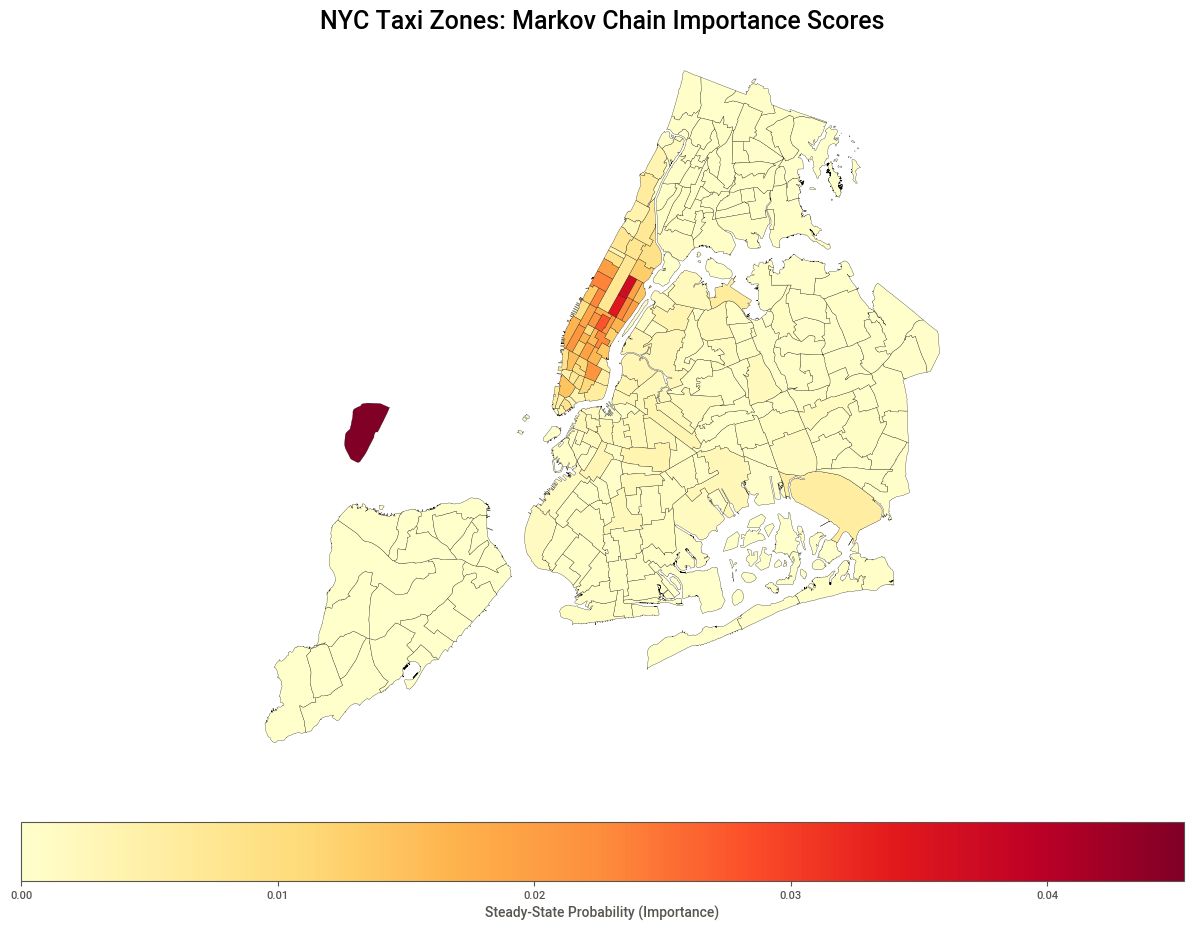

In [416]:
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import shape  # Use 'shape' for GeoJSON/Dictionaries
import pandas as pd

# 1. Convert GeoJSON dictionaries to actual Geometry objects
# We check if it's a dict (GeoJSON) or a string (WKT) to be safe
def parse_geometry(geom):
    if isinstance(geom, dict):
        return shape(geom) # Converts GeoJSON dict to Polygon
    elif isinstance(geom, str):
        from shapely import wkt
        return wkt.loads(geom) # Converts WKT string to Polygon
    return geom

geo_df['the_geom'] = geo_df['the_geom'].apply(parse_geometry)

# 2. Convert to GeoDataFrame
geo_df = gpd.GeoDataFrame(geo_df, geometry='the_geom')

# 3. Set Coordinate System (NYC Open Data uses WGS84)
geo_df.set_crs(epsg=4326, inplace=True)

# 4. Clean IDs for merging
geo_df['locationid'] = geo_df['locationid'].astype(int)
df_results['LocationID'] = df_results['LocationID'].astype(int)

# 5. Dissolve (Merge the 263 polygons into your 260 unique IDs)
geo_df_combined = geo_df.dissolve(by='locationid', aggfunc='first').reset_index()

# 6. Merge with Markov Results
map_data = geo_df_combined.merge(df_results, left_on='locationid', right_on='LocationID')

# 7. Visualize
fig, ax = plt.subplots(1, 1, figsize=(15, 12))
map_data.plot(
    column='Importance_Score', 
    ax=ax, 
    legend=True, 
    cmap='YlOrRd',         
    edgecolor='black',     
    linewidth=0.2,         
    legend_kwds={
        'label': "Steady-State Probability (Importance)", 
        'orientation': "horizontal",
        'pad': 0.05
    }
)

ax.set_title("NYC Taxi Zones: Markov Chain Importance Scores", fontsize=18)
ax.axis('off') 
plt.show()

In [415]:
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely import wkt
import pandas as pd

# 1. Convert 'the_geom' strings to actual Geometry objects
# We do this before converting to a GeoDataFrame
if isinstance(geo_df['the_geom'].iloc[0], str):
    geo_df['the_geom'] = geo_df['the_geom'].apply(wkt.loads)

# 2. Convert to GeoDataFrame explicitly naming the geometry column
geo_df = gpd.GeoDataFrame(geo_df, geometry='the_geom')

# 3. Set Coordinate System (NYC Open Data uses WGS84)
geo_df.set_crs(epsg=4326, inplace=True)

# 4. Ensure 'locationid' is an integer for consistent merging
geo_df['locationid'] = geo_df['locationid'].astype(int)
df_results['LocationID'] = df_results['LocationID'].astype(int)

# 5. Dissolve to get your 260 unique regions
# This merges the 263 polygons into your 260 unique IDs
geo_df_combined = geo_df.dissolve(by='locationid', aggfunc='first').reset_index()

print(f"Success! Map now has {len(geo_df_combined)} unique zones.")

# 6. Merge with your Markov Importance Scores
map_data = geo_df_combined.merge(df_results, left_on='locationid', right_on='LocationID')

# 7. Create the Figure and Plot
fig, ax = plt.subplots(1, 1, figsize=(15, 12))

map_data.plot(
    column='Importance_Score', 
    ax=ax, 
    legend=True, 
    cmap='YlOrRd',         
    edgecolor='black',     
    linewidth=0.2,         
    legend_kwds={
        'label': "Steady-State Probability (Importance)", 
        'orientation': "horizontal",
        'pad': 0.05  # Increased padding slightly for better spacing
    }
)

# 8. Final Touches
ax.set_title("NYC Taxi Zones: Markov Chain Importance Scores", fontsize=18)
ax.axis('off') 

plt.show()

TypeError: Input must be valid geometry objects: {'type': 'MultiPolygon', 'coordinates': [[[[-74.18445299999996, 40.69499599999993], [-74.18448899999999, 40.69509499999991], [-74.18449799999996, 40.69518499999991], [-74.18438099999997, 40.69587799999992], [-74.18428199999994, 40.69621099999994], [-74.18402099999997, 40.69707499999992], [-74.18391299999996, 40.69750699999991], [-74.18375099999997, 40.697794999999914], [-74.18363399999998, 40.69832599999993], [-74.18356199999994, 40.69845199999991], [-74.18354399999998, 40.69855999999993], [-74.18350799999996, 40.69870399999994], [-74.18327399999998, 40.70008999999991], [-74.18315699999994, 40.70121499999992], [-74.18316599999997, 40.702384999999914], [-74.18313899999998, 40.702627999999926], [-74.18309399999998, 40.702852999999934], [-74.18299499999995, 40.70315899999989], [-74.18284199999994, 40.70346499999992], [-74.18264399999998, 40.703734999999924], [-74.18242799999996, 40.703950999999954], [-74.18220299999996, 40.70413999999993], 

In [ ]:
geo_df.describe()

the_geom  \
count                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               